# IMDb Prediction - Modelagem Preditiva

Aqui vamos trabalhar a construção de um modelo preditivo que se aproxime de inferir a questão desse projeto. Queremos descobrir o nível mais próximo possível de predição de nota do IMDb para um filme, dadas as informações contidas no portal sobre ele. 

## Preparação de Features

Iniciaremos verificando as features disponíveis no conjunto de dados a fim de reparar valores que possam prejudicar a predição, como valores faltantes, outliers e duplicatas. Como estamos trabalhando com um dataset pequeno, não nos daremos ao luxo de exclusão de valores. 

In [19]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import seaborn as sn
import mlflow
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

from datetime import date

from scipy.stats.mstats import winsorize

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler

from pathlib import Path
from wordcloud import WordCloud


warnings.filterwarnings('ignore')
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
root = Path("ML.ipynb").resolve().parent.parent
os.chdir(root)

df_imdb = pd.read_csv("Data/raw/desafio_indicium_imdb.csv")


**Imputação em valores faltantes:**

Vemos que existe pouca quantidade de variáveis que possuam valores faltantes, e um valor proximo de 10% a 15% de linhas com valores faltantes. A saída mais satisfatória nesse caso é o uso da mediana para imputação em numericos, em especial em "Meta_score" que possui uma distribuição mais similar à normal. No caso dos textuais, uma tag de desconhecido será o suficiente. 

In [2]:
df_imdb.isna().sum()

Unnamed: 0         0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [20]:
df_imdb["Certificate"] = df_imdb["Certificate"].fillna("UNK")

df_imdb["Meta_score"] = df_imdb["Meta_score"].astype(float)
df_imdb["Meta_score"] = df_imdb["Meta_score"].fillna(df_imdb["Meta_score"].median())

df_imdb["Gross"] = pd.to_numeric(df_imdb["Gross"].str.replace(",", ""), errors="coerce")
df_imdb["Gross"] = df_imdb["Gross"].fillna(df_imdb["Gross"].median())

df_imdb["Runtime"] = df_imdb["Runtime"].map(lambda x: int(x.split()[0]))

df_imdb.loc[df_imdb["Released_Year"] == "PG", "Released_Year"] = '1995'

**Tratamento de Outliers:**

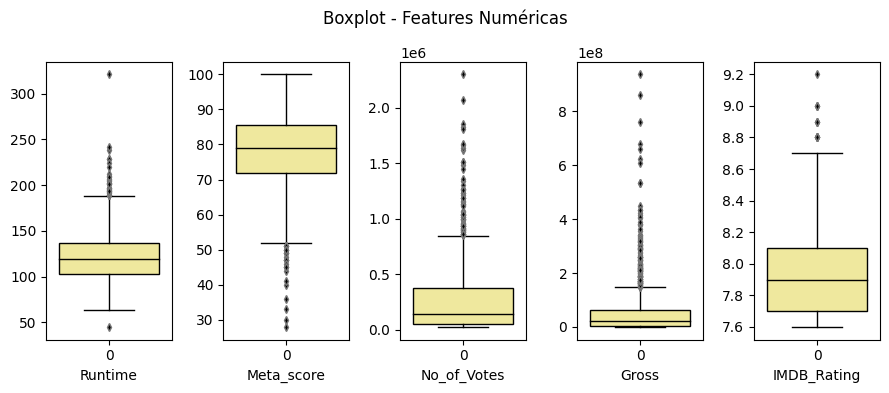

In [4]:
number_cols = ["Runtime", "Meta_score", "No_of_Votes", "Gross", "IMDB_Rating"]

fig, ax = plt.subplots(1, len(number_cols), figsize=(9, 4))

for c in range(len(number_cols)):
    sn.boxplot(data=df_imdb[number_cols[c]], ax=ax[c], color="#fcf390",
               boxprops=dict(edgecolor="black", linewidth=1),
               medianprops=dict(color="black", linewidth=1),
               capprops=dict(color="black", linewidth=1),
               whiskerprops=dict(color="black", linewidth=1),
               flierprops=dict(markerfacecolor="black", markersize=4))
    ax[c].set_xlabel(number_cols[c])
    ax[c].set_ylabel("")

fig.suptitle("Boxplot - Features Numéricas", y=.97)
plt.tight_layout()
plt.show()

In [5]:
print("Porcentagem de Outliers")
for c in number_cols:
    Q1, Q3 = df_imdb[c].quantile(0.25), df_imdb[c].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df_imdb[c] < (Q1 - 1.5 * IQR)) | (df_imdb[c] > (Q3 + 1.5 * IQR))
    percent = df_imdb[mask].count()[0]/df_imdb.count()[0]

    print(f"{c}: {(percent*100):.1f}%")

Porcentagem de Outliers
Runtime: 2.9%
Meta_score: 2.5%
No_of_Votes: 6.6%
Gross: 12.4%
IMDB_Rating: 1.2%


Com a noção do tamanho desse dataset, sabemos que 1% equivale a muito pouco dos dados. Tomaremos o limite de 3% de outliers como threshold nas variáveis numéricas.<br>

Assumindo a legitimidade dos valores, mas também a influencia do desequilibrio da distribuição, a escolha será seletiva: trataremos os dois outliers mais severos:"Gross" e "No_of_Votes". A estratégia será Winsorizar os valores no percentil que representa maior discrepância. Como "Gross" possui quase o dobro de taxa de outlier de "No_of_Votes", vamos diminuir o corte pela metade:

In [21]:
df_imdb["Gross"] = winsorize(df_imdb["Gross"], limits=[0.0, 0.124])
df_imdb["Runtime"] = winsorize(df_imdb["Runtime"], limits=[0.0, 0.081])
df_imdb["Meta_score"] = winsorize(df_imdb["Meta_score"], limits=[0.025, 0.0])
df_imdb["No_of_Votes"] = winsorize(df_imdb["No_of_Votes"], limits=[0.0, 0.066])

Antes de começar o processo de preparação dos dados, vamos segmentá-los destinados a cada uso:

In [7]:
index_train, index_test = train_test_split(df_imdb.index, test_size=0.25, random_state=42)

**Codificação - variáveis textuais**

Além das variáveis categóricas ("Genre", "Certificate", "Released_Year"), o dataset conta com informação textual de grande importância que acaba sendo considerada valor único. É o caso de "Overview", "Series_Title", "Director" e as variáveis de elenco principal ("Stars"). 

Com variáveis categóricas que possuem muitas categorias, como "Released_Year", vamos transformar a informação de forma que mantenha seu valor e nos permita economizar dimensionalidade.<br><br>
Para as variáveis "Director" e Stars que são altamente categóricas, mas possuem importância de contexto, foi pensada uma codificação especial baseada em scores.

In [ ]:

class EncodeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, imdb_rating, number_cols):
        self.imdb_rating = imdb_rating
        self.number_cols = number_cols
        self.stars_cols_ = [f"Star{s}" for s in range(1,5)]
        self.training_ = True
        self.columns_ = None

        self.dict_genres_ = {}
        self.dict_certs_ = {}
        self.actor_score_ = {}
        self.bias_feature_ = {}
        self.director_ = {}
        self.global_mean_values_ = {}
        self.scaler_ = None

    def get_columns(self):
        return self.columns_
    
    def __save_columns(self, df):
        self.columns_ = list(df.columns)
    
    def __director_fit(self, df):
        def mean_excluding_self(group):
            return group.apply(lambda x: group[group != x].mean() 
                             if len(group[group != x]) > 0 else mean_value)
        
        df_temp = df.copy()
        df_temp["IMDB_Rating"] = self.imdb_rating.loc[df.index]
        self.global_mean_values_["imdb"] = mean_value = self.imdb_rating.mean()
        means = df_temp.groupby("Director")["IMDB_Rating"].apply(mean_excluding_self)
        self.director_["mean_imdb"] = means.groupby("Director").mean()

        self.global_mean_values_["metascore"] = mean_value = df["Meta_score"].mean()
        means = df_temp.groupby("Director")["Meta_score"].apply(mean_excluding_self)
        self.director_["mean_meta"] = means.groupby("Director").mean()

    def __director_transform(self, df):
        dir_imdb_transform = df["Director"].map(
            lambda x: self.director_["mean_imdb"].get(x, self.global_mean_values_["imdb"]))
        dir_meta_transform = df["Director"].map(
            lambda x: self.director_["mean_meta"].get(x, self.global_mean_values_["metascore"]))
        
        return pd.concat([dir_imdb_transform, dir_meta_transform], axis=1, 
                    keys=["DirectorIMDB", "DirectorMS"])
    
    def __generate_score(self, df):
        name_col = self.stars_cols_
        y_subset = self.imdb_rating.loc[df.index]

        existing_star_cols = [col for col in name_col if col in df.columns]
    
        if not existing_star_cols:
            self.actor_score_ = {0 : [0.0, 0.0, 0.0, 0.0]}
            return

        all_actors = pd.concat([df[s] for s in name_col]).unique()
        count_stars = [df[s].value_counts() for s in name_col]

        enc = OneHotEncoder(sparse_output=False)
        df_stars = pd.DataFrame(enc.fit_transform(df[name_col]), 
                    columns=list(enc.get_feature_names_out(name_col)), 
                    index=df.index)

        S_scaled = StandardScaler().fit_transform(df_stars.values)
        model_lasso = LassoCV(cv=5, random_state=42)
        model_lasso.fit(S_scaled, y_subset.values)

        df_coef = pd.DataFrame({"feat": df_stars.columns, "coef": model_lasso.coef_})
        df_coef["pos"] = df_coef["feat"].apply(lambda x: x.split("_")[0])
        self.bias_feature_ = df_coef.groupby("pos")["coef"].mean().to_dict()

        for actor in all_actors:
            count = [c.get(actor, 0) for c in count_stars]
            points = 0
            for i in range(4):
                points += (count[i] * self.bias_feature_[f"Star{i+1}"])
            prop = [cnt/len(df) for cnt in count]

            self.actor_score_[actor] = [points/prop[s] if prop[s] != 0 else 0.0 for s in range(4)]

    def __get_score(self, actor, col):
        try:
            score = self.actor_score_[actor][self.stars_cols_.index(col)]
        except KeyError:
            score = 0.0
        return score

    def __genres_fit(self, df):
        infos = {"No_of_Votes": "mean"}
        genres =  " ".join(df["Genre"].astype(str).tolist()).replace(",", "").split()
        self.dict_genres_ = {k: self.__group_category(df, k, "Genre", infos)[0] for k in set(genres)}
    
    def __group_category(self, df, cat_names, cat,  info):
        list_info = []
        for i in info.keys():
            df_col = df[df[cat].str.contains(cat_names, na=False)]
            result = getattr(df_col[i], info[i])()
            list_info.append(result)
        return list_info
    
    def __genre_transform(self, df):
        def map_values(genre_line):
            list_values = [self.dict_genres_[i] for i in genre_line.split(", ")]
            return sum(list_values)/len(list_values)
        
        df["Genre"] = df["Genre"].map(map_values)

        return df[["Genre"]]
    
    def __cert_fit(self, df):
        infos = {"No_of_Votes": "mean"}
        certs =  set(df["Certificate"].to_list())
        self.dict_certs_ = {k: self.__group_category(df, k, "Certificate", infos)[0] for k in certs}
    
    def __cert_transform(self, df):
        df["Certificate"] = df["Certificate"].map(lambda x: self.dict_certs_.get(x, 0.0))
        return df[["Certificate"]]
    
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler()
        self.mlb_ = MultiLabelBinarizer()
        self.one_hot_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        
        self.__director_fit(X)
        self.__genres_fit(X)
        self.__cert_fit(X)
        
        self.__generate_score(X)

        self.training_ = True
        self.scaler_.fit(self.transform(X))
        self.training_ = False

        return self
    
    def transform(self, X):
        df_col = X.copy()
        df_final = pd.DataFrame()

        df_final = pd.concat([df_final, self.__director_transform(df_col)], axis=1)
        df_final = pd.concat([df_final, self.__genre_transform(df_col)], axis=1)
        df_final = pd.concat([df_final, self.__cert_transform(df_col)], axis=1)

        for col in self.stars_cols_:
            df_final[col] = df_col[col].apply(lambda x: self.__get_score(x, col))

        df_final["Released_Year"] = df_col["Released_Year"].map(
            lambda x: (date.today().year - int(x))
        )

        df_final = pd.concat([df_final, df_col[self.number_cols]], axis=1)
        self.__save_columns(df_final)

        if not self.training_:
            X_transformed = self.scaler_.transform(df_final.values)
        else:
            X_transformed = df_final.values

        return X_transformed

## Modelagem Preditiva

Nesse momento desenvolveremos a abordagem de predição. É importante lembrar que existem etapas de pré processamento necessárias para garantir um resultado consistente nesse conjunto de dados. Aqui modificaremos a nota do IMDb, que segue um limite inferior e superior, se mantendo dentro do range **[0.0, 10.0]**. Será necessário a adaptação dos modelos explorados para adotar essa regra.<br><br>

Para isso, escolhemos manter os valores target dentro de um intervalo de segurança entre [0.0, 1.0]. Isso é feito reduzindo uma casa decimal no valor e restringindo todos os valores a um conjunto onde o máximo não passe de **0.999999** e mínimo não passe de **0.000001**. Assim evitamos valores de y onde a função logaritmica receberia divisão por 0.

In [9]:
def transform_y(Y):
    y_normalized = Y.to_numpy() / 10.0
    y_normalized = np.clip(y_normalized, 1e-6, (1 - 1e-6))
    transformed = np.log(y_normalized / (1 - y_normalized))
    return pd.DataFrame(transformed, columns=["IMDB_Rating"])

def detransform_y(y_transformed):
    y_normalized = 1 / (1 + np.exp(-y_transformed))
    y_original = y_normalized * 10.0
    return y_original

def create_custom_scorer(metric, greater=True):
    def custom_metric(y_true_trans, y_pred_trans):
        y_true_trans = np.asarray(y_true_trans).flatten()
        y_pred_trans = np.asarray(y_pred_trans).flatten()    

        y_true = detransform_y(y_true_trans)
        y_pred = detransform_y(y_pred_trans)
        return metric(y_true, y_pred)
    
    return make_scorer(custom_metric, greater_is_better=greater)

**Preparando avaliação de Modelos:**<br><br>

A estratégia de treinamento durante o GridSearch contemplou um pipeline carregado com a divisão de treinamento dos dados, que foi usada no decorrer dos experimentos do MLFlow em etapas divididas na definição de função acima:
<br><br>
1 - Subdivisão do conjunto de treinamento para GridSearch entre treino e teste<br>
2 - Treinamento comum com o grid search utilizando uma unica fold para seleção primária de argumentos e evitar custo de processamento<br>
3 - Refit do modelo com todo o subconjunto de treino<br>
4 - Avaliação honesta do modelo com o subconjunto de teste
<br><br>
Assim conseguimos na visualização de runs do experimento uma noção de métricas para treino e teste, sendo possível avaliar qual modelo oferece maior ou menor Overfitting.

In [10]:
def run_experiment(pipe, params, name, mlflow_log, exp_id):
    df_x = df_imdb.drop(columns=["IMDB_Rating", "Series_Title", "Overview"])
    df_y = transform_y(df_imdb["IMDB_Rating"])

    scores = {
        'r2': create_custom_scorer(r2_score, greater=True),
        'mse': create_custom_scorer(mean_squared_error, greater=False),
        'mae': create_custom_scorer(mean_absolute_error, greater=False),
        'rmse': create_custom_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), 
                                greater=False)
    }

    X_train, X_test, Y_train, Y_test = train_test_split(
        df_x.loc[index_train], df_y.loc[index_train], test_size=0.25, random_state=42
    )
    single_split = ShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    mlflow.set_experiment(experiment_id=exp_id)
    mlflow_log.autolog()

    if mlflow.active_run():
        mlflow.end_run()

    with mlflow.start_run(run_name=name):
        grid_search = GridSearchCV(pipe, 
                        params, 
                        cv=single_split,
                        scoring=scores,
                        refit="r2",
                        verbose=2,
                        n_jobs=6)
        
        grid_search.fit(X_train, Y_train)

        y_test_original = detransform_y(Y_test)
        best_model = grid_search.best_estimator_
        y_test_pred = detransform_y(best_model.predict(X_test))

        mlflow.log_metrics({
            "best_cv_score": grid_search.best_score_,
            "honest_test_r2": r2_score(y_test_original, y_test_pred),
            "honest_test_mse": mean_squared_error(y_test_original, y_test_pred),
            "honest_test_mae": mean_absolute_error(y_test_original, y_test_pred)
        })
        
        print(f"Melhores parâmetros: {grid_search.best_params_}")
        print(f"Melhor score: {grid_search.best_score_:.4f}")
    
    return best_model

A escolha de modelo feita aqui será RandomForestRegression, exemplar que garante bom processamento com ruídos, menor taxa de Overfitting, lida bem com alta dimensionalidade dos conjuntos de dados e tem uma estrutura robusta para enfrentar Outliers (que são uma preocupação nossa nesse projeto). Vamos utilizar um modelo permutável (GridSearch) e avaliar suas versões para cada variação de hiperparâmetros.

In [ ]:
params = {'model__max_depth': [8, 9, 10], 
          'model__max_features': [0.3, 0.4, 0.5], 
          'model__min_samples_leaf': [8, 10, 12], 
          'model__min_samples_split': [15, 18, 20], 
          'model__n_estimators': [300]}

numeric_cols = number_cols[:-1]
rating_ref = df_imdb["IMDB_Rating"].loc[index_train]

pipe = Pipeline([
    ("preprocessor", EncodeTransformer(rating_ref, numeric_cols)),
    ("model", RandomForestRegressor())
])

name_run = "RFR - Re-encoding"
exp_id = 874457680861546167
pipeline = run_experiment(pipe, params, name_run, mlflow.sklearn, exp_id)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


2025/10/17 21:27:22 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.


Melhores parâmetros: {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 8, 'model__min_samples_split': 15, 'model__n_estimators': 300}
Melhor score: 0.4593


Text(0.5, 1.0, 'Importância das Features para o Modelo')

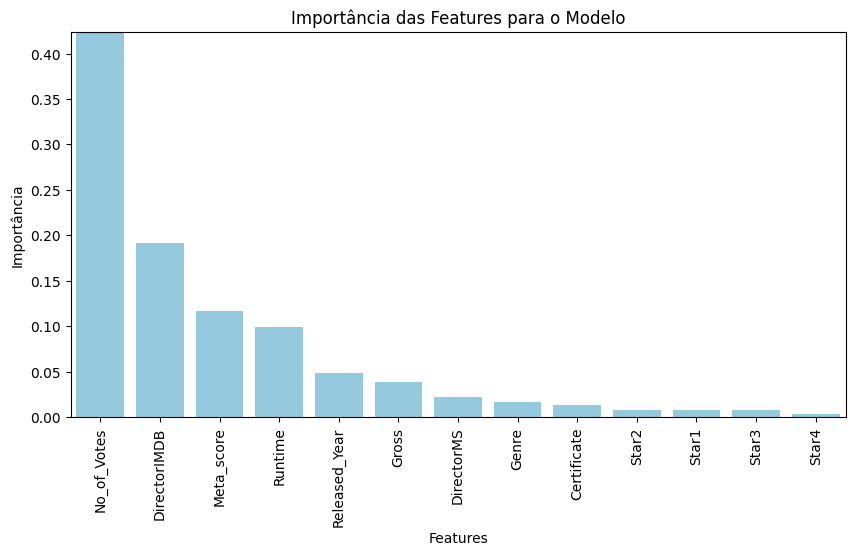

In [12]:
cols = pipeline.named_steps['preprocessor'].get_columns()
importances = pipeline.named_steps['model'].feature_importances_
importances = pd.DataFrame(data=importances, index=cols, columns=["Value"])
importances.sort_values(by="Value", ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
sn.barplot(data=importances, y="Value", x=importances.index, ax=ax, color="skyblue")
ax.set_ylim(0, importances.max().iloc[0])
ax.set_ylabel("Importância")
ax.set_xlabel("Features")
ax.tick_params(axis='x', rotation=90)
plt.title("Importância das Features para o Modelo")

**Teste da Versão Selecionada**

Vamos recarregar o modelo registrado no MLFlow e retreiná-lo usando a divisão de treino em 80% dos dados usando um Kfold mais eficiente dessa vez para observar resultados:

In [13]:
from sklearn.model_selection import KFold

def retraining_mlflow_model(model, X, y, n_splits=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = {'r2': [], 'mse': [], 'mae': []}

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        x_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model.fit(x_train_fold, y_train_fold)
        
        y_pred = model.predict(X_val_fold)
        y_pred_original = detransform_y(y_pred)
        y_val_original = detransform_y(y_val_fold.values.flatten())
    
        scores['r2'].append(r2_score(y_val_original, y_pred_original))
        scores['mse'].append(mean_squared_error(y_val_original, y_pred_original))
        scores['mae'].append(mean_absolute_error(y_val_original, y_pred_original))

    return scores

2025/10/17 21:28:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e9e6f377606540ab9181923d6fa67884', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/10/17 21:30:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '179f7a24b1e943c58a3706d045b6f12a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/10/17 21:31:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f47fd1cb66b0489cb9f07fe057f80aa8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/10/17 21:32:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9134a5e7f2904537a0542d45d58f5b9f', which will track hyperparameters, performance metrics, model artifacts, and lineage i

=== Resultados Retreino K-Fold = 5 ===
MSE médio: 0.04
MAE médio: 0.16
R2 médio: 0.44


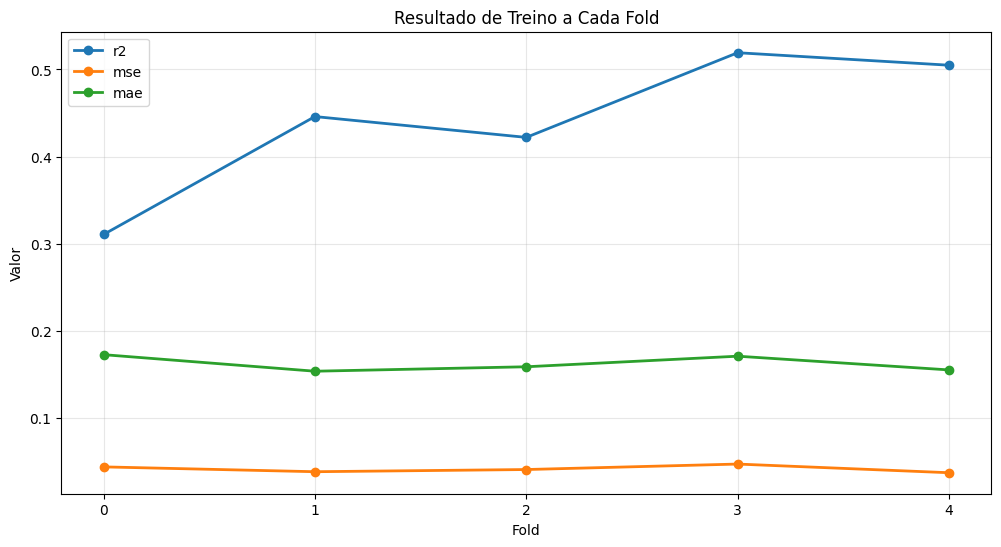

In [ ]:

path_model = 'mlflow-artifacts:/874457680861546167/92d1b4960b924940b28f75629882f5fe/artifacts/best_estimator'
loaded_model = mlflow.sklearn.load_model(path_model)

numeric_cols = number_cols[:-1]
rating_ref = df_imdb["IMDB_Rating"].loc[index_train]

X_train = df_imdb.drop(columns=["IMDB_Rating"]).loc[index_train]
Y_train = transform_y(df_imdb["IMDB_Rating"].loc[index_train])

results_retrain = retraining_mlflow_model(loaded_model, X_train, Y_train, n_splits=5)

print("=== Resultados Retreino K-Fold = 5 ===")
print(f"MSE médio: {sum(results_retrain['mse'])/5:.2f}")
print(f"MAE médio: {sum(results_retrain['mae'])/5:.2f}")
print(f"R2 médio: {sum(results_retrain['r2'])/5:.2f}")

df = pd.DataFrame(results_retrain)
df.plot(figsize=(12, 6), marker='o', linewidth=2)
plt.title('Resultado de Treino a Cada Fold')
plt.xticks([i for i in range(5)])
plt.xlabel('Fold')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [15]:
X_test = df_imdb.drop(columns=["IMDB_Rating"]).loc[index_test]
Y_test = transform_y(df_imdb["IMDB_Rating"].loc[index_test])

Y_pred = detransform_y(loaded_model.predict(X_test))
Y_true = detransform_y(Y_test)

print("=== Resultados Teste ===")
print(f"MSE: {mean_squared_error(Y_true, Y_pred):.3f}")
print(f"MAE: {mean_absolute_error(Y_true, Y_pred):.3f}")
print(f"R2: {r2_score(Y_true, Y_pred):.3f}")

=== Resultados Teste ===
MSE: 0.048
MAE: 0.177
R2: 0.329


In [24]:
with open("model/model.pkl", "wb") as f:
    pickle.dump(loaded_model.named_steps["model"], f)